## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this second laboratory we will gain some experience working with Transformer models for a variety tasks using (mostly) the Hugging Face Ecosystem. 


---
### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Loading the Dataset Splits
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [1]:
# Dataset imports.
from datasets import load_dataset, get_dataset_split_names
import numpy as np
import matplotlib.pyplot as plt
import torch

slag = 'cornell-movie-review-data/rotten_tomatoes'
#load scarica dataset, get rende i nomi degli split
# Non è un url ma uno slag
splits = get_dataset_split_names(slag)

In [2]:
splits

['train', 'validation', 'test']

We use the function to understand how it is divided the dataset. This function is proposed by Hugging Faces, Hugging Faces with the library __dataset__ can access to some datasets with a easy access.

In [3]:
ds_dict = {split : load_dataset(slag, split= split) for split in splits}

When using Hugging Face Datasets, loading a dataset involves two main phases:
- downloading: the library retrieves the raw data files (such as JSON or CSV) from a remote repository and stores them locally in a cache.
- generating: , these raw files are parsed, processed, and converted into an optimized internal format (based on Apache Arrow), creating structured dataset objects for each split (e.g., train, validation, test).

These two steps are separated to improve efficiency: once the data is downloaded, it can be reused from the cache, while the generation step ensures fast access and processing during subsequent uses.

In [4]:
ds_dict

{'train': Dataset({
     features: ['text', 'label'],
     num_rows: 8530
 }),
 'validation': Dataset({
     features: ['text', 'label'],
     num_rows: 1066
 }),
 'test': Dataset({
     features: ['text', 'label'],
     num_rows: 1066
 })}

So, the training set has 8530 couple of text and label. Meanwhile the dataset split as validation and test have a size of 1066.
Here below, we have printed ten movie review where the label is:
- 1: if the review is positive.
- 0: if the review is negative.

In [37]:
import numpy as np
#Estrarre da questo dizionario il train dataset e visualizzo qualche esempio di training set.
ds_train = ds_dict['train']
ds_test = ds_dict['test']
ds_validation = ds_dict['validation']
for row in np.random.permutation(len(ds_train))[:10]:
    row = int(row)
    print(f"{ds_train[row]['label']}: {ds_train[row]['text']}")

0: the screenplay comes across , rather unintentionally , as hip-hop scooby-doo .
0: . . . a boring parade of talking heads and technical gibberish that will do little to advance the linux cause .
0: if you think that jennifer lopez has shown poor judgment in planning to marry ben affleck , wait till you see maid in manhattan .
1: presents an astute appraisal of middle american musical torpor and the desperate struggle to escape it .
1: this cuddly sequel to the 1999 hit is a little more visually polished , a little funnier , and a little more madcap .
0: this is nothing but familiar territory .
0: the film has [its] moments , but they are few and far between .
1: it will grip even viewers who aren't interested in rap , as it cuts to the heart of american society in an unnerving way .
0: just an average comedic dateflick but not a waste of time .
0: pumpkin struts about with " courage " pinned to its huckster lapel while a yellow streak a mile wide decorates its back .


Etichette trovate: [0, 1]
Conteggi assoluti: [4265, 4265]


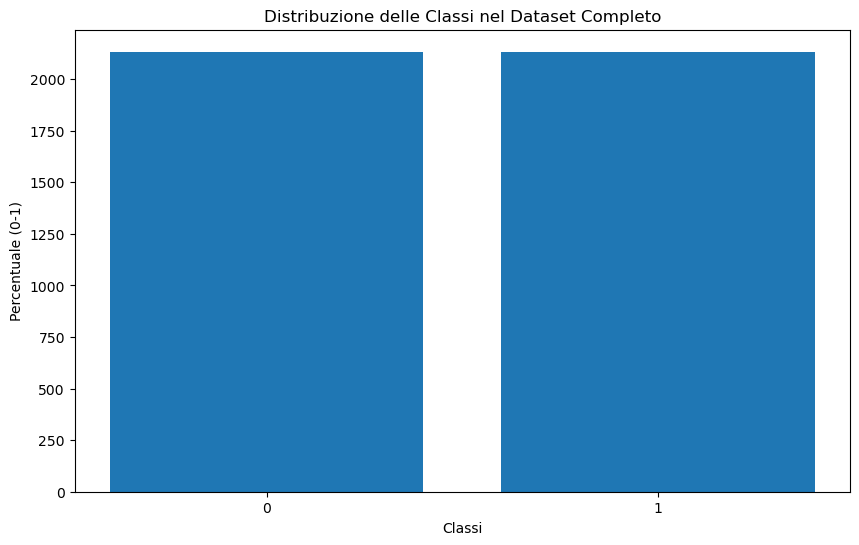

In [6]:
from collections import Counter

#Distribution of dataset
def plot_distribution(ds_dict):
    labels = []
    
    labels.extend(ds_dict["train"]['label'])

    label_counts = Counter(labels)        
        
    
    
    labels = sorted(label_counts.keys())
    counts = [label_counts[l] for l in labels]
    
    total_elements = len(labels)
    percentages = [c / total_elements for c in counts]
    
    print(f"Etichette trovate: {labels}")
    print(f"Conteggi assoluti: {counts}")
    
    # 5. Disegniamo il grafico
    plt.figure(figsize=(10, 6))
    
    bars = plt.bar(labels, percentages)
    
    plt.xticks(labels)
    plt.xlabel("Classi")
    plt.ylabel("Percentuale (0-1)")
    plt.title("Distribuzione delle Classi nel Dataset Completo")
    
    plt.show()
    
plot_distribution(ds_dict)

The training dataset is bilanced, so we haven't problem in a possible training.


---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the DistilBERT model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

As first serious exercise, we can load using the library __transformers__ a pretrained BERT model and his tokenizer. Also, this libra

In [7]:
# AutoClass imports.
from transformers import AutoTokenizer, AutoModel

model = AutoModel.from_pretrained('distilbert/distilbert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('distilbert/distilbert-base-uncased')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


_____

After loading the model, we can encode an example sentence.
The encoding process transforms a text string into a sequence of integers, where each integer corresponds to a token from a predefined vocabulary.

In [8]:
token_example1 = tokenizer.encode('This is a sample sentence', return_tensors='pt')
print(token_example1[0])
token_example2 = tokenizer.encode('Another sample sentence', return_tensors='pt')
print(token_example2[0])

tensor([ 101, 2023, 2003, 1037, 7099, 6251,  102])
tensor([ 101, 2178, 7099, 6251,  102])


Each number represents a specific token. In particular:
- 101 corresponds to the special token \[CLS\], which marks the beginning of the sentence and is used for classification tasks.
- 102 corresponds to the special token \[SEP\], which marks the end of the sentence (or separates two sentences).

Decoding the first sequence gives:

In [9]:
tokenizer.decode(token_example1) 

['[CLS] this is a sample sentence [SEP]']

So, the numerical tensors shown above are simply the tokenized representation of the input sentences, where each token is mapped to its corresponding ID in the model's vocabulary.

##### Analysis of the Model

In this small paragraph, we will talk about the architecture of the model. 

In [10]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

We can analyze the model architecture by dividing it into two main components:

1. Embedding Layer

This is the entry point of the model, where input tokens are transformed into dense numerical vectors.

- Word Embeddings (30522, 768):
The model uses a vocabulary of 30,522 tokens (words or subwords). Each token is mapped to a 768-dimensional vector. When a token is provided as input, its corresponding row in the embedding matrix is selected as its vector representation.
- Position Embeddings (512, 768):
Since Transformers process tokens in parallel, they do not inherently capture word order. Positional embeddings address this by encoding the position of each token in the sequence (up to 512 tokens). These vectors are summed with the word embeddings to incorporate order information.
- LayerNorm (768):
Normalizes the embedding vectors to stabilize and accelerate training.
- Dropout:
Randomly deactivates a subset of neurons during training to reduce overfitting.

2. Transformer Blocks

The core of the model consists of multiple stacked Transformer blocks (e.g., 6 layers), each responsible for refining the token representations.

- Multi-Head Self-Attention:


  Each block includes linear projections for:
    - Query (Q)
    - Key (K)
    - Value (V)
      
    These projections allow the model to compute attention scores, determining how much each token should focus on others in the sequence.
For example, in the sentence "The bank of the river", the attention mechanism helps the model understand that "bank" refers to a riverbank rather than a financial institution, by considering its context.

- Feed-Forward Network (FFN): After the attention step, each token representation is processed independently through a feed-forward network:
    - Linear (768 → 3072): Expands the representation to a higher-dimensional space to capture more complex patterns.
    - Linear (3072 → 768): Projects it back to the original dimension.
- GELU Activation:
A non-linear activation function applied between the two linear layers, enabling the model to learn complex relationships in the data.

___

Now, we could make an inference with this model, taking two sentences and analizing the output.

In [11]:
batch = ds_dict["train"][:2]["text"]
print("Example:")
for b in batch:
    words = b.split()
    print(f"{b} -LEN: {len(words)}")
print("\n")
print("Tokens Structure:")
tokens = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
print(tokens.keys())


Example:
the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal . -LEN: 34
the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth . -LEN: 39


Tokens Structure:
KeysView({'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102,     0,     0,     0,
             0,     0],
        [  101,  1996,  9882,  2135,  9603, 13633,  1997,  1000,  1996,  2935,
          1997,  1996,  763

So, the tokenizer returned item has returned a structure that is composed by three fields:
- input_ids: this field contains all id token to maps the embedding for each sentence. We can see after the Separetor Token some zeros. This is the padding each input must have the same dimention before entering in the Trasform block so the extra token are filled with zeros.
- token_type_ids: if a input is formed by more than one sentence this field provides to distinguish the first sentence from the second one.
- attention_mask: it provides to distinguish all token that are important for the inference.

We can see this behavior, using:

In [12]:
tokenizer.decode(tokens["input_ids"])

['[CLS] the rock is destined to be the 21st century \' s new " conan " and that he \' s going to make a splash even greater than arnold schwarzenegger, jean - claud van damme or steven segal. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD]',
 '[CLS] the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co - writer / director peter jackson \' s expanded vision of j. r. r. tolkien \' s middle - earth. [SEP]']

There's particular tokens as:
- \[CLS\] $\Rightarrow$ Class Token
- \[SEP\]: $\Rightarrow$ Separation Token
- \[PAD\]: $\Rightarrow$ Padding Token

In [13]:
tokens = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")

output = model(**tokens)

print(output.keys())
print(output.last_hidden_state.shape)
output.last_hidden_state[0]

odict_keys(['last_hidden_state'])
torch.Size([2, 52, 768])


tensor([[-0.0332, -0.0168,  0.0194,  ...,  0.0476,  0.5834,  0.3036],
        [-0.0235, -0.0555, -0.3638,  ...,  0.1877,  0.5781, -0.1577],
        [-0.0516, -0.1014, -0.1511,  ...,  0.1503,  0.2649, -0.1575],
        ...,
        [ 0.3688, -0.1147,  0.8428,  ..., -0.0708, -0.0178, -0.2516],
        [ 0.0654, -0.0206,  0.1889,  ...,  0.1159,  0.2323, -0.2404],
        [ 0.0373, -0.0104,  0.1203,  ...,  0.1049,  0.2852, -0.3035]],
       grad_fn=<SelectBackward0>)

The output has this dimension $[2, 52, 768]$. We have two results composed of 52 tokens each. If we look closely, we can see that when we printed the inputs, the number of words was less than 52. This is because the tokenizer decomposes the sentences into sub-words (tokens) and adds special tokens like [CLS] and [SEP], plus padding to match the longest sentence.The output represents the hidden states (or contextual embeddings) of this sentence, not the logits. This is because the model used here is a base Encoder without a language modeling head.

0 is a padding token $\rightarrow$ all prompt thats have lenght minor must add these tokens to make all prompts of the same dimention.

In [14]:
logits = output.last_hidden_state[0]
word_embeddings = model.embeddings.word_embeddings.weight

word = torch.matmul(logits, word_embeddings.T)


predicted_ids = torch.argmax(word, dim=-1)
print(tokenizer.decode(predicted_ids))

[CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] boca [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] [CLS] schwarzene [CLS] [CLS] [CLS] - [CLS] [CLS] van dam [CLS] [CLS] [CLS] [CLS] [CLS]veyoit [CLS] [CLS] [CLS] [CLS] [CLS]


By projecting the entire last_hidden_state back to the vocabulary space, we can visualize the internal representation of each token. While many tokens gravitate towards the [CLS] vector due to the attention mechanism's global context, key entities like 'Schwarzenegger' or 'Van Damme' maintain a strong individual identity. This proves that the Encoder is not just a passive filter, but it reshapes the vectors to emphasize the most informative parts of the input.

Another method to make an inference with the model, is using forward. and we can use like this:

In [15]:
# Sta costruendo questi  argomenti nominati (keys) da passare al modello. Questo è equivalente a fare forward(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
# MA SE NON C'È la chiave corrispondente?

masking = model.forward(
    input_ids=tokens['input_ids'], 
    attention_mask=tokens['attention_mask']
)
not_masking = model.forward(
    input_ids=tokens['input_ids'])


print("Masking: ")
print(masking)
print("\n Not Masking: ")
print(not_masking)


Masking: 
BaseModelOutput(last_hidden_state=tensor([[[-0.0332, -0.0168,  0.0194,  ...,  0.0476,  0.5834,  0.3036],
         [-0.0235, -0.0555, -0.3638,  ...,  0.1877,  0.5781, -0.1577],
         [-0.0516, -0.1014, -0.1511,  ...,  0.1503,  0.2649, -0.1575],
         ...,
         [ 0.3688, -0.1147,  0.8428,  ..., -0.0708, -0.0178, -0.2516],
         [ 0.0654, -0.0206,  0.1889,  ...,  0.1159,  0.2323, -0.2404],
         [ 0.0373, -0.0104,  0.1203,  ...,  0.1049,  0.2852, -0.3035]],

        [[-0.2062, -0.0490, -0.4036,  ..., -0.1186,  0.6141,  0.3919],
         [-0.4361, -0.1647, -0.3533,  ...,  0.1086,  0.9478, -0.0272],
         [-0.1164,  0.1690,  0.2698,  ..., -0.1971,  0.4372,  0.2527],
         ...,
         [-0.2341,  0.4810, -0.2634,  ..., -0.3397,  0.2567,  0.1274],
         [ 0.7139,  0.0574, -0.3260,  ...,  0.2041, -0.3800, -0.3343],
         [ 0.5649,  0.2806, -0.0295,  ...,  0.1297, -0.3160, -0.1874]]],
       grad_fn=<NativeLayerNormBackward0>), hidden_states=None, attentio

The comparison between 'Masking' and 'Not Masking' highlights the fundamental role of the Attention Mask.

- **Data Contamination:** Without the mask, the model's self-attention mechanism incorporates padding tokens (zeros) into the mathematical representation of real words. This results in slightly different vectors (Hidden States) for the same input words, as seen in the first sentence.

- **Batch Consistency:** The second sentence remains unchanged because it has no padding; therefore, the mask (all ones) is functionally redundant for that specific entry.

- **Reliability:** This experiment confirms that masking is essential to ensure that the 'contextual meaning' of a sentence is derived only from actual content and not from the technical artifacts (padding) needed for batch processing.


---
### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use DistilBERT as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [16]:
from transformers import pipeline
import torch
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

extractor = pipeline('feature-extraction', model = model, tokenizer = tokenizer)
feats = extractor(list(ds_train['text']), return_tensors='pt')# List perchè deve essere una sequenza non una colonna

In [17]:
len(feats)

8530

In [18]:
feats[0].shape

torch.Size([1, 47, 768])

In [19]:
feats[1].shape

torch.Size([1, 52, 768])

As we have already said the central number it can change and it depends by the segmentation of the sentence.

In [20]:
features=torch.vstack([feat[0][0] for feat in feats])

In [21]:
features.shape

torch.Size([8530, 768])

In [22]:
import copy
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import pipeline
import wandb
from sklearn.svm import LinearSVC

input_dim = len(features[0]) 

configuration = {
    "SVC": {
        "class": LinearSVC,
        "params": {
            "dual": "auto",       
            "max_iter": 2000,    
            "C": 1.0,            
            "random_state": 42
        },
        "type": "sklearn"
    },
    "Linear": {
        "model": nn.Sequential(
            nn.Linear(768, 1, bias=True),
            nn.Sigmoid()
        ),  
        "params": {
            "batch_size": 16,
            "lr": 1e-3,
            "epochs": 20
        },
        "type": "pytorch"
    },
    "MLP": {
        "model": nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2),     
            nn.Linear(256, 1),
            nn.Sigmoid()
        ),
        "params": {
            "lr": 1e-3,            
            "epochs": 20,
            "batch_size": 16
        },
        "type": "pytorch"
    }
}

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval() 
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad(): 
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            
            predictions = (outputs > 0.5).float()
            correct += (predictions == batch_y).sum().item()
            total += batch_y.size(0)
            
    return val_loss / len(loader), correct / total

def extraction(hf_model, tokenizer, ds, device_id):
    print("Extraction of the all CLS Tokens\n\n")
    extractor = pipeline('feature-extraction', model=hf_model, tokenizer=tokenizer, device=device_id)

    ds_train = ds["train"]
    ds_val = ds["validation"]
    ds_test = ds["test"]
    
    feats_training = extractor(list(ds_train['text']))
    feats_validation = extractor(list(ds_val['text']))
    feats_test = extractor(list(ds_test['text']))
    
    X_train = torch.stack([torch.tensor(f)[0, 0, :] for f in feats_training])
    X_val = torch.stack([torch.tensor(f)[0, 0, :] for f in feats_validation])
    X_test = torch.stack([torch.tensor(f)[0, 0, :] for f in feats_test])
    
    y_train = torch.tensor(ds_train["label"], dtype=torch.float32).view(-1, 1)
    y_val = torch.tensor(ds_val["label"], dtype=torch.float32).view(-1, 1)
    y_test = torch.tensor(ds_test["label"], dtype=torch.float32).view(-1, 1)

    return X_train, y_train, X_val, y_val, X_test, y_test

def training(string_model, configuration, X_train, y_train, X_val, y_val, device):
    print(f"Training the {string_model} classificator\n\n")
    
    if string_model not in configuration:
        return None
    
    conf = configuration[string_model]
    
    wandb.init(
        project="nlp",
        name=f"run-{string_model}",
        config=conf["params"] 
    )
    
    if conf["type"] == "sklearn":
        classificator = conf["class"](**conf["params"])
        classificator.fit(X_train.numpy(), y_train.numpy().ravel())
        wandb.finish()
        return classificator
        
    else:
        classificator = conf.get("model") if "model" in conf else conf["class"](**conf["params"])
        classificator.to(device)
        
        lr = conf["params"].get("lr", 0.001)
        epochs = conf["params"].get("epochs", 10)
        batch_size = conf["params"].get("batch_size", 32)
        
        criterion = nn.BCELoss()
        optimizer = optim.Adam(classificator.parameters(), lr=lr)
        
        dataset_train = TensorDataset(X_train, y_train)
        dataset_val = TensorDataset(X_val, y_val)
        
        loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
        loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)
        
        best_loss = float('inf')
        epochs_no_improve = 0    
        patience = 5
        best_model_wts = copy.deepcopy(classificator.state_dict())
        
        for epoch in range(epochs):
            avg_train_loss = train_one_epoch(classificator, loader_train, criterion, optimizer, device)
            avg_val_loss, val_acc = evaluate(classificator, loader_val, criterion, device)
            
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
                "val_accuracy": val_acc
            })
            
            if avg_val_loss < best_loss:
                best_loss = avg_val_loss
                epochs_no_improve = 0
                best_model_wts = copy.deepcopy(classificator.state_dict())
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                break 

        classificator.load_state_dict(best_model_wts)
        wandb.finish()
        return classificator

def test_model(string_model, trained_model, configuration, X_test, y_test, device):
    if trained_model is None:
        return None
        
    conf = configuration[string_model]
    print(f"Testing {string_model} on Test Set...\n\n")
    
    wandb.init(
        project="nlp",
        name=f"test-{string_model}",
        config=conf["params"]
    )
    
    if conf["type"] == "sklearn":
        test_acc = trained_model.score(X_test.numpy(), y_test.numpy().ravel())
        
        wandb.log({"test_accuracy": test_acc})
        print(f"{string_model} Test Accuracy: {test_acc:.4f}\n")
        result = test_acc
        
    else:
        batch_size = conf["params"].get("batch_size", 32)
        dataset_test = TensorDataset(X_test, y_test)
        loader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)
        criterion = nn.BCELoss()
        
        trained_model.to(device)
        test_loss, test_acc = evaluate(trained_model, loader_test, criterion, device)
        
        wandb.log({
            "test_loss": test_loss,
            "test_accuracy": test_acc
        })
        #print(f"{string_model} Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}\n")
        result = test_acc
        
    wandb.finish()
    return result
    

def baseline(hf_model, tokenizer, ds_dict, configuration):
    wandb.login()
    models = ["SVC", "Linear", "MLP"]
    
    if torch.cuda.is_available():
        device_id = 0
        device = torch.device("cuda")
    else:
        device_id = -1
        device = torch.device("cpu")
        
    X_train, y_train, X_val, y_val, X_test, y_test = extraction(hf_model, tokenizer, ds_dict, device_id)
    
    trained_models = {}
    test_results = {}
    for m in models:
        trained_models[m] = training(m, configuration, X_train, y_train, X_val, y_val, device)
        test_results[m] = test_model(m, trained_models[m], configuration, X_test, y_test, device)
    return trained_models, test_results

In [23]:
trained_models, test_results = baseline(model, tokenizer, ds_dict, configuration)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/deste00/.netrc.
wandb: Currently logged in as: marco-destefano1 (marco-destefano1-universit-degli-studi-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Extraction of the all CLS Tokens


Training the SVC classificator




Testing SVC on Test Set...




SVC Test Accuracy: 0.7983



test_accuracy,▁
test_accuracy,0.79831


...

test_accuracy,▁
test_loss,▁
test_accuracy,0.79737
test_loss,0.43368


Training the MLP classificator




epoch,▁▂▂▃▄▄▅▅▆▇▇█
train_loss,█▅▄▄▃▃▃▂▂▂▁▁
val_accuracy,▁▇▁▆▅▁█▇▂▅▆█
val_loss,█▃▅▂▂▅▁▂▆▄▃▅
epoch,12
train_loss,0.37714
val_accuracy,0.82176
val_loss,0.4142


Testing MLP on Test Set...




test_accuracy,▁
test_loss,▁
test_accuracy,0.79174
test_loss,0.44074


In [24]:
test_results

{'SVC': 0.798311444652908,
 'Linear': 0.797373358348968,
 'MLP': 0.7917448405253283}

---
---
## Exercise 2: Fine-tuning DistilBERT

In this exercise we will fine-tune the DistilBERT model to (hopefully) improve sentiment analysis performance.


---
### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits -- we don't want to re-tokenize our inputs for every batch! Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do by hand, but the Hugging Face `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [38]:

def preprocess_function(examples):
    return tokenizer(examples['text'],padding= True, return_tensors='pt' ,truncation = True)

tokenized_train = ds_train.map(preprocess_function, batched=True)
tokenized_test = ds_test.map(preprocess_function, batched=True)
tokenized_validation = ds_validation.map(preprocess_function, batched=True)

Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

According to the Hugging Face documentation, the .map() function applies a user-defined function to each element of the dataset. When the parameter batched=True is set, the dataset is processed in batches, with the batch size controlled by the batch_size parameter (which defaults to 1000).

When .map() is applied to a dataset, it can also add new columns based on the output of the applied function.

In [26]:
ds_train

Dataset({
    features: ['text', 'label'],
    num_rows: 8530
})

In [ ]:
tokenized_train

In [ ]:
tokenized_train.set_format('pt', columns=['input_ids'], output_all_columns=True)
tokenized_test.set_format('pt', columns=['input_ids'], output_all_columns=True)
tokenized_validation.set_format('pt', columns=['input_ids'], output_all_columns=True)

Another important function is set_format, which allows specifying how the dataset columns should be returned. For instance, it can be used to convert columns such as input_ids into PyTorch tensors, while leaving the other columns unformatted.

In [1]:
tokenized_train

NameError: name 'tokenized_train' is not defined

In [2]:
tokenized_train['input_ids'][0]

NameError: name 'tokenized_train' is not defined

As shown above, the input_ids column contains tensors representing the tokenized version of each sentence, where each integer corresponds to a specific token in the vocabulary.


---
### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [3]:
from transformers import AutoModelForSequenceClassification

# Hugging Face - automazione
cls_model = AutoModelForSequenceClassification.from_pretrained('distilbert/distilbert-base-uncased', num_labels=2)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


The AutoModelForSequenceClassification class is a wrapper around a pretrained model, in this case based on DistilBERT. It can be seen as a container that uses DistilBERT as the encoder (backbone) and adds a classification head on top of it.

In [5]:
cls_model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


As shown in the printed architecture, the model consists of the DistilBERT encoder followed by a fully connected classification head. In particular, after the transformer backbone, there is a linear layer (pre-classifier), followed by a dropout layer and a final classifier layer that maps the hidden size (768) to the number of output classes (2 in this case).

This confirms that the model performs sequence classification by taking the encoded representation (of size 768) and projecting it into the target label space.

So, we could try to make some inferences.

In [30]:
tokens = tokenizer(ds_train[0]['text'], return_tensors='pt', padding = 'max_length', max_length=512)
cls_model.forward(tokens['input_ids'])

SequenceClassifierOutput(loss=None, logits=tensor([[ 0.0470, -0.0992]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [42]:
tokens = tokenizer(ds_train[0]['text'], return_tensors='pt', padding='max_length', max_length=512)

label = torch.tensor([ds_train[0]['label']])

outputs = cls_model(**tokens, labels=label)

print(f"Loss calcolata in automatico: {outputs.loss}")
print(f"Logits: {outputs.logits}")

Loss calcolata in automatico: 0.704384982585907
Logits: tensor([[-0.0195, -0.0418]], grad_fn=<AddmmBackward0>)


Although we ran inference using the same model, we obtained different logits. Why did this happen?
This is due to two main reasons:

- Missing Attention Mask: In the first case, we didn't pass the attention mask. Without it, the model couldn't distinguish between actual text and padding tokens, meaning it processed a lot of padding zeros as real words.

- Dropout Layers: The model's architecture includes Dropout layers. Since the model was in training mode, Dropout randomly deactivated a percentage of neurons during the forward pass. Because of this randomness, the same input will always produce a slightly different outpu


---
### Exercise 2.3: Fine-tuning DistilBERT

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [39]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    # eval_pred è una tupla contenente (logits, labels) fornita dal Trainer
    logits, labels = eval_pred
    
    # I logits sono i punteggi grezzi per ogni classe. 
    # Prendiamo l'indice (0 o 1) con il valore più alto per ogni frase.
    predictions = np.argmax(logits, axis=-1)
    
    # Calcoliamo le metriche con Scikit-learn
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    
    # Il Trainer si aspetta in ritorno un dizionario
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Si userà le classi fornite da Hugging Faces, ci pensa il Trainer ad eseguire il Training Loop. Ci manca da fare una cosa. Elementi in uno stesso batch sono di lunghezza differente. Quindi, in hugging face si usa **DataCollatorWithPadding**, tra dataset e ottimizzatore

In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Using Gemini I can understand the difference from Data Collator and DataLoader. 

Infact the first one is a specialized component responsible for taking a list of individual, unformatted data samples retrieved by the DataLoader and assembling them into uniform, batched tensors ready for the model's consumption.

In Natural Language Processing (NLP), its most critical role is applying dynamic padding: instead of padding the entire dataset to a fixed absolute maximum length beforehand, the collator examines each specific batch, identifies the longest sequence within it, and pads all shorter sequences with zeros just enough to match that local maximum length. It also generates the corresponding attention masks to ensure the model ignores these added padding tokens.

This dynamic assembly process guarantees that the neural network receives the strictly rectangular matrices it mathematically requires, while significantly optimizing memory usage and computational speed during training.

In [44]:

training_args = TrainingArguments(
    output_dir='./distilbert-rotten-tomatoes', # Where saving the weights models.
    num_train_epochs=3,                        
    per_device_train_batch_size=16,            # Dimention of the batch in training
    per_device_eval_batch_size=64,             # Batch bigger than eval 
    weight_decay=0.01,                         # Regularization to avoid the overfitting
    eval_strategy="epoch",               # evaluation of the model at the end of each epochs
    save_strategy="epoch",                     # Save the model at the end of each epochs
    load_best_model_at_end=True,               # At the end of the training the best model is loaded
    logging_dir='./logs',
    report_to="wandb"                          
)


trainer = Trainer(
    model=cls_model,                    # Model
    args=training_args,                 # Arguments of the class
    train_dataset=tokenized_train,      # Training Datasets
    eval_dataset=tokenized_validation,         # Validation Datasets
    processing_class=tokenizer,         # Tokenizer to process the input.
    data_collator=data_collator,        # The DataCollaitor to padding all inputs
    compute_metrics=compute_metrics,    
)

# 4. Via al training! (Mettiti comodo e aspetta)
print("Start of the fine-tuning...")
trainer.train()

# 5. Valutazione finale
print("\nCalculating all metrics on the Validation Set...")
eval_results = trainer.evaluate()

print("\n--- Final Results ---")
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Avvio del fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.412117,0.387911,0.839587,0.851434,0.792880,0.919325
2,0.210448,0.460960,0.849906,0.849057,0.853890,0.844278
3,0.093819,0.660111,0.848030,0.849442,0.841621,0.857411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Calcolo delle metriche sul Validation Set...


Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.093819,0.387911,3,0.839587,0.851434,0.792880,0.919325



--- Risultati Finali ---
eval_loss: 0.3879
eval_accuracy: 0.8396
eval_f1: 0.8514
eval_precision: 0.7929
eval_recall: 0.9193


So, using the fine-tuning on the model Distilbert marks a significant improvement over the baseline static feature extraction approach, demonstrating the effectiveness of updating the Transformer's internal weights for the specific domain of movie reviews.

The fine-tuned model achieved an overall accuracy of 83.96% and an F1-score of 85.14%, proving to be highly effective on the Rotten Tomatoes dataset.

The evaluation metrics highlight a specific behavior: with a recall of 91.93% and a precision of 79.29%, the model is exceptionally good at capturing positive reviews, though it tends to over-predict the positive class, resulting in a higher rate of false positives. Overall, the low validation loss (0.3879) and the high F1-score demonstrate a successful training phase and a robust final classifier.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! Or if you want to propose something else as a third exercise, reach out to me on the Discord!


---
### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis

In Exercise 2 we fine-tuned the *entire* Distilbert model on Rotten Tomatoes. This is expensive, even for a small model. Find an *efficient* way to fine-tune Distilbert on the Rotten Tomatoes dataset (or some other dataset).

**Hint**: You could check out the [HuggingFace PEFT library](https://huggingface.co/docs/peft/en/index) for some state-of-the-art approaches that should "just work". How else might you go about making fine-tuning more efficient without having to change your training pipeline from above?

**Why choose this exercise?** PEFT techniques -- especially LoRA are the methods of choice for adapting models to new tasks.

In [ ]:
# Your code here. (Easy) Finetuning tutto rischio di overfittare - pochi dati per adattare il modello.
#Insieme di tecniche Lora, Prompt Learning


---
### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

**Why choose this exercise?** CLIP is probably the most widely used Vision-Language Model, and adapting it is a useful skill to master.

In [ ]:
# Your code here.
# Più difficile perchè c'è un alto dataset - interessante usare un dataset imagenet sketch


---
### Exercise 3.3: A Text-to-image Retrieval System (hard, but not *too* hard)

Implement a simple text-to-image retrieval system with a simple user interface --- using, for example, [gradio](https://www.gradio.app/), or [Marimo](https://marimo.io/), or [Shiny](https://shiny.posit.co/). Your application should *index* (e.g. compute visual descriptors for) a small dataset of images like [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k). It should provide a user interface with which a user can enter a short text prompt (e.g. "a photo of dogs playing in the snow") and then display the top-10 matching images from the indexed dataset.

Note that there is no following code block with "Your code here" for this exercise. You will definitely want to implement this outside of a Jupyter Notebook.

**Hint**: The **CLIP** model is practically *made* for just such an application.

**Why choose this exercise?** Well, this is a course on Deep Learning *Applications*, and this is your chance to *build* one!

#### It is choosed this exercise. The script is in the folder "DLA_Second_Laboratory"

---
---